<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/code/basicGAN/GAN_lstm_global_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [ ]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
%cd drive/My\ Drive/

[Errno 2] No such file or directory: 'drive/My Drive/'
/content/drive/My Drive


## load data

In [ ]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [ ]:
### BINARY TRAJ

nb_traj = 500
length = 200
traj = np.zeros((nb_traj, length))

for i in range(nb_traj):
    l = np.random.randint(2,length/2)
    st = np.random.randint(1, length-l-1)

    traj[i,st:st+l] = 1

In [ ]:
class TrajDataSet(Dataset):
    def __init__(self,  traj, transform=None):
        
        self.traj = traj   # save trips
        self.transform = transform

    def __len__(self):
        return self.traj.shape[0]

    def __getitem__(self, idx):
        sample = traj[idx,:]
        if self.transform:
            sample = self.transform(sample)
        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""
    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [ ]:
# hyperparameters
batch_size = 100

## reduce size dataset
train_set = TrajDataSet(traj, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [ ]:
x =  next(iter(train_loader))

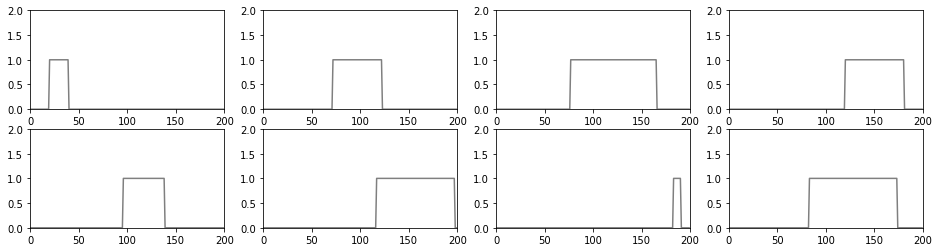

In [ ]:
plt.figure(figsize = (16,4))

for i in range(8):
  plt.subplot(2,4,i+1)
  plt.plot(x.numpy()[i,:], c = 'black', alpha = 0.5)
  plt.xlim(0,length)
  plt.ylim(0,2)


## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [ ]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

## LSTM

In [ ]:
class LSTMGenerator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(5, 20, 1, batch_first=True, bias = True)
        self.linear = nn.Sequential(
                        nn.Tanh(),
                        nn.Linear(20, 20),
                        nn.Tanh(),
                        nn.Linear(20, 20),
                        nn.Tanh(),
                        nn.Linear(20, 1),
                        nn.Tanh()
                      )

    def forward(self, x):  

        h_0 = torch.autograd.Variable(torch.randn(1, batch_size, 20)) #hidden state
        c_0 = torch.autograd.Variable(torch.randn(1, batch_size, 20)) #internal stat

        # init LSTM cells  (batch, seq, feature)
        out, (h_n, c_n) = self.lstm(x, (h_0, c_0))
        out = self.linear(out)
        out = out.view(batch_size, 1, 200)
        return out #torch.cumsum(out, 2)

In [ ]:
gen = LSTMGenerator()
z = torch.rand((batch_size, 200, 5)) # (batch, features, len)

out = gen(z)
out.shape

torch.Size([100, 1, 200])

In [ ]:
class CNNDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

                
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 8,  kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(8, 16,  kernel_size = 4, stride = 2, padding = 1, bias = False),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(16, 1, kernel_size=50, stride=2, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):

        out = self.cnn(x.view((batch_size, 1, 200)))
        return out.squeeze(1)


In [ ]:
dis = CNNDiscriminator()
dis(x).shape

torch.Size([100, 1])

In [ ]:
sum(p.numel() for p in gen.parameters())

2701

# training

In [ ]:
def weights_init(m):
    """
    This function initializes the model weights randomly from a 
    Normal distribution. This follows the specification from the DCGAN paper.
    https://arxiv.org/pdf/1511.06434.pdf
    Source: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# generator = CNNGenerator().to(device)
generator = LSTMGenerator().to(device)
discriminator = CNNDiscriminator().to(device)
# discriminator = LSTMDiscriminator().to(device)


# ### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

lr = 0.0002
optim_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

Epoch [1/5000] -----------------------------------------------------------------------------
G: 0.7414567470550537, Dr : 0.7223597019910812, Df : 1.0330544263124466


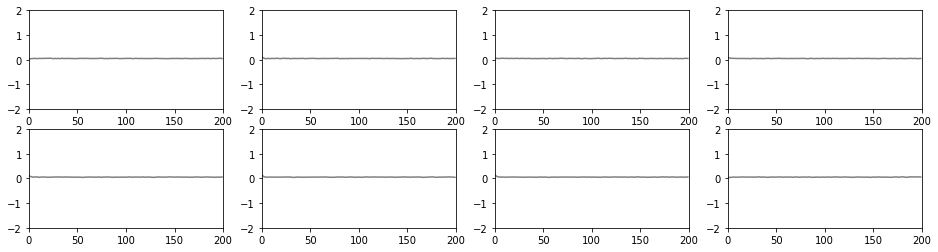

Epoch [201/5000] -----------------------------------------------------------------------------
G: 6.237940788269043, Dr : 0.023914281744509935, Df : 0.013680426520295441


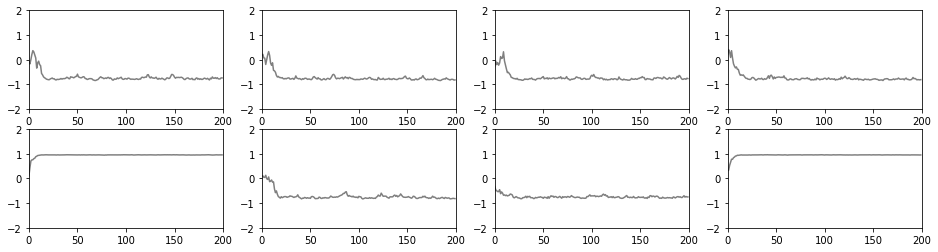

Epoch [401/5000] -----------------------------------------------------------------------------
G: 9.015270948410034, Dr : 0.0015203996445052326, Df : 0.0012197871110402048


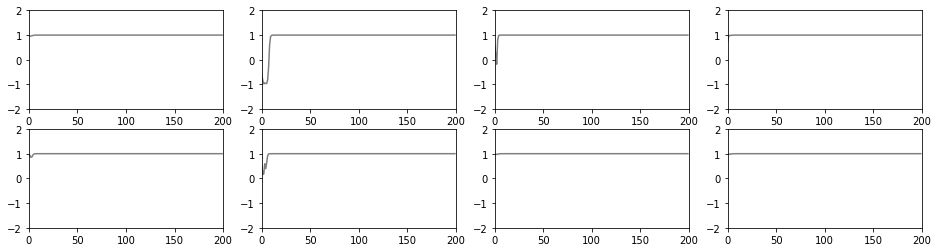

Epoch [601/5000] -----------------------------------------------------------------------------
G: 10.544509649276733, Dr : 0.0005404230396379717, Df : 0.00040382098814006895


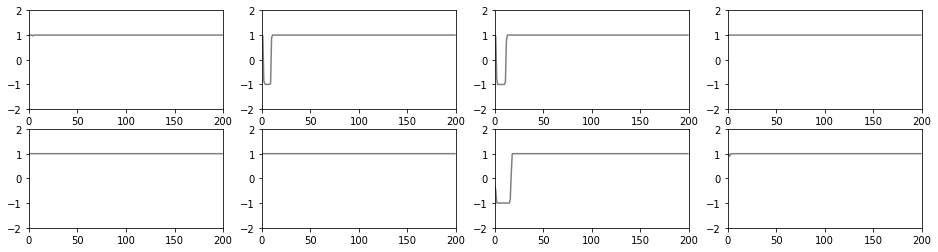

Epoch [801/5000] -----------------------------------------------------------------------------
G: 11.482784032821655, Dr : 0.0002439258387312293, Df : 0.00019961883663199842


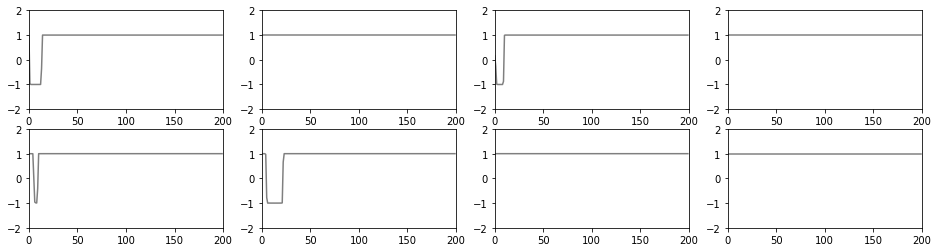

Epoch [1001/5000] -----------------------------------------------------------------------------
G: 6.261475682258606, Dr : 0.045709919184446335, Df : 0.01921727997250855


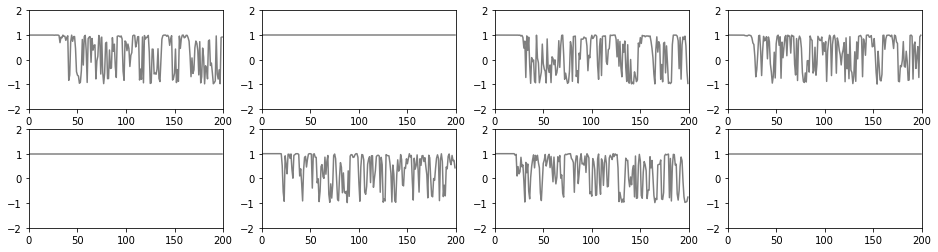

Epoch [1201/5000] -----------------------------------------------------------------------------
G: 9.512567639350891, Dr : 0.0034812104422599077, Df : 0.0015423675795318559


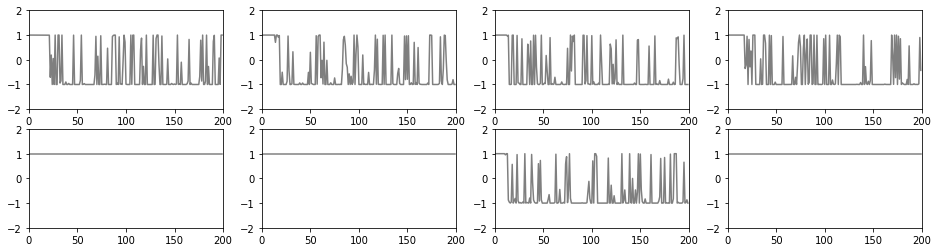

Epoch [1401/5000] -----------------------------------------------------------------------------
G: 10.196098923683167, Dr : 0.0018139857274945825, Df : 0.0020114911894779652


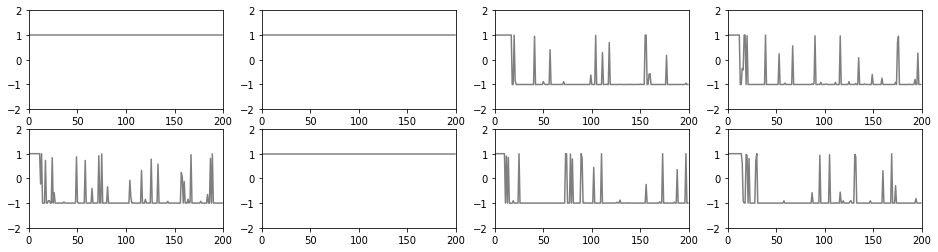

Epoch [1601/5000] -----------------------------------------------------------------------------
G: 11.716072082519531, Dr : 0.0006990231267991476, Df : 0.0002990237844642252


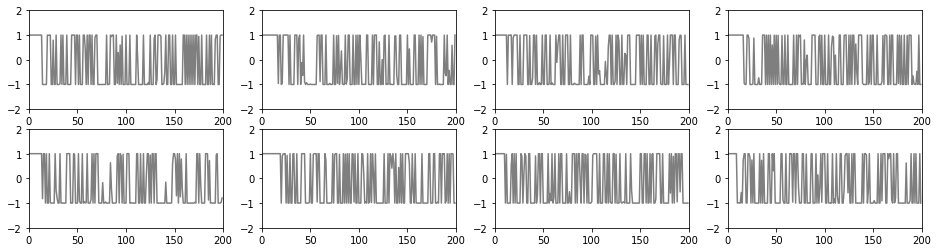

Epoch [1801/5000] -----------------------------------------------------------------------------
G: 11.587626934051514, Dr : 0.0003576348753995262, Df : 0.00048504979349672794


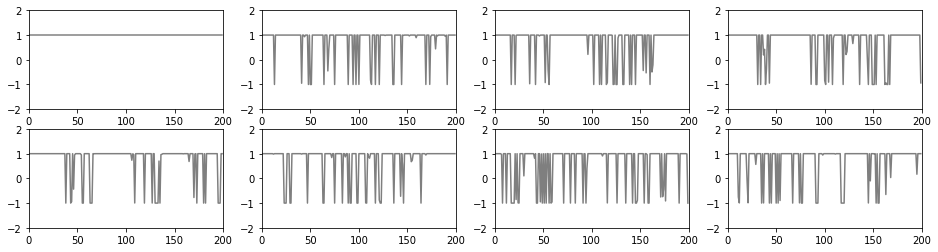

Epoch [2001/5000] -----------------------------------------------------------------------------
G: 12.984485864639282, Dr : 0.0003869359425152652, Df : 0.0005396043925429694


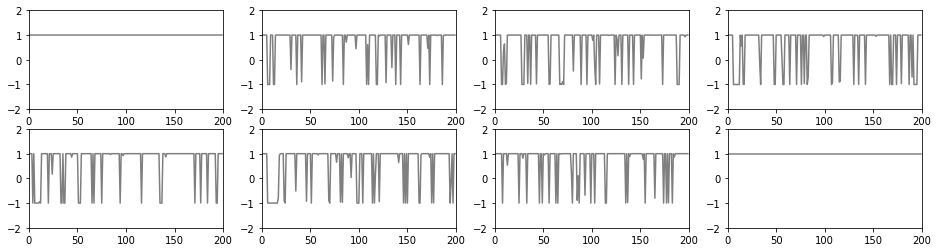

Epoch [2201/5000] -----------------------------------------------------------------------------
G: 15.248735189437866, Dr : 0.0005280459954519756, Df : 0.0008572207007091492


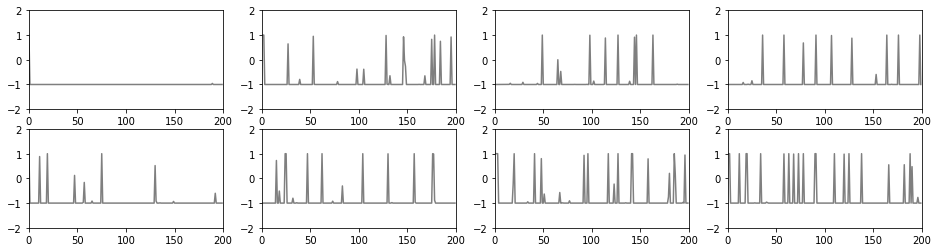

Epoch [2401/5000] -----------------------------------------------------------------------------
G: 13.164076805114746, Dr : 0.00011560466919036116, Df : 0.00011860400081786793


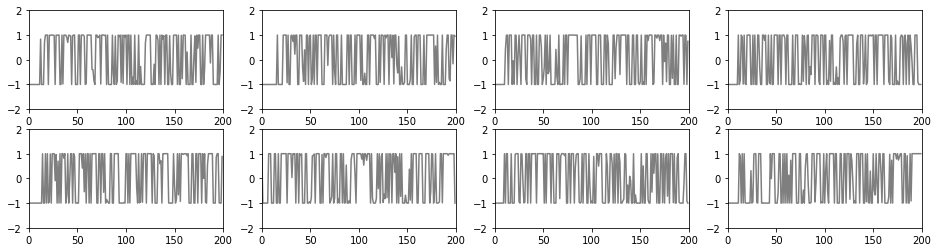

Epoch [2601/5000] -----------------------------------------------------------------------------
G: 13.618556022644043, Dr : 6.104222120484337e-05, Df : 4.078482334080036e-05


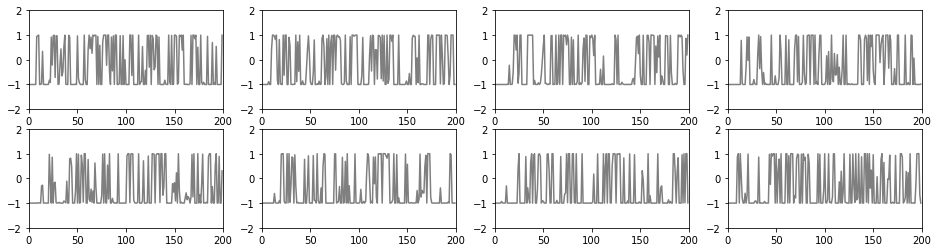

Epoch [2801/5000] -----------------------------------------------------------------------------
G: 14.489481687545776, Dr : 2.2286538069238304e-05, Df : 2.183739775318827e-05


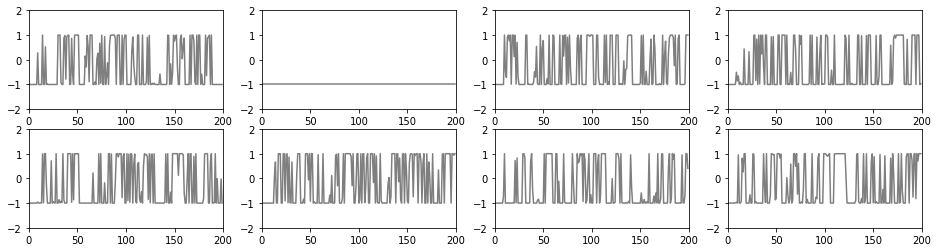

Epoch [3001/5000] -----------------------------------------------------------------------------
G: 11.777295351028442, Dr : 0.0007770706288283691, Df : 0.0005622406788461376


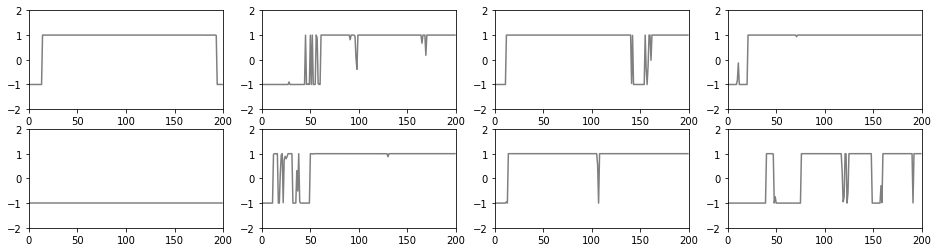

Epoch [3201/5000] -----------------------------------------------------------------------------
G: 11.14555025100708, Dr : 0.00039132751408033073, Df : 0.0005535190721275285


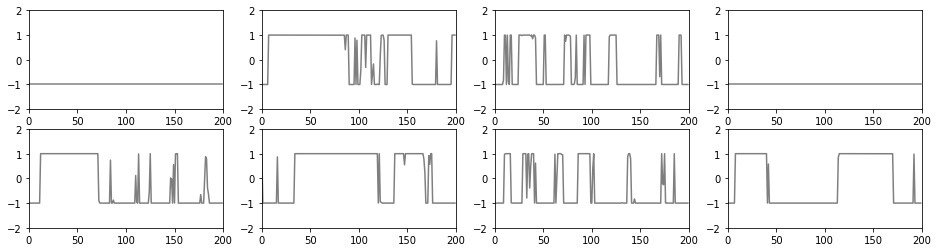

Epoch [3401/5000] -----------------------------------------------------------------------------
G: 12.107691526412964, Dr : 0.00010415666474727914, Df : 0.0001760218929121038


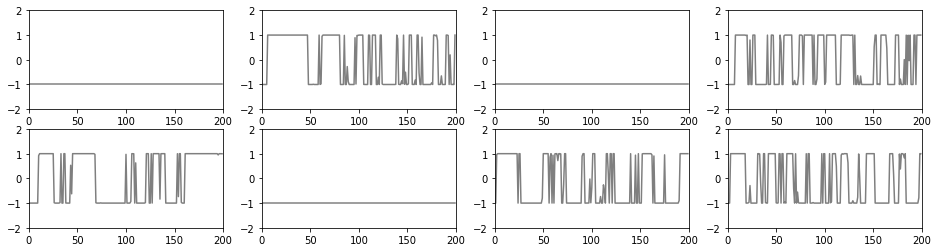

Epoch [3601/5000] -----------------------------------------------------------------------------
G: 16.32099986076355, Dr : 7.6881470704393e-05, Df : 2.687452752070385e-05


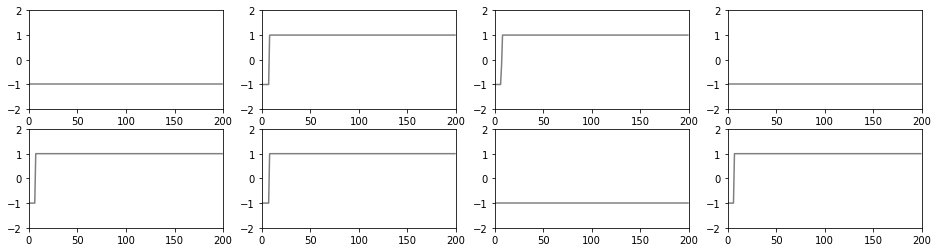

Epoch [3801/5000] -----------------------------------------------------------------------------
G: 13.584107637405396, Dr : 4.265790494173416e-05, Df : 6.0345566453179345e-05


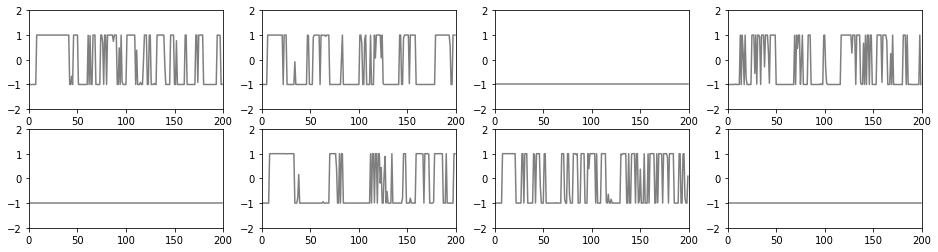

Epoch [4001/5000] -----------------------------------------------------------------------------
G: 14.329346895217896, Dr : 2.698747175600147e-05, Df : 3.242700904593221e-05


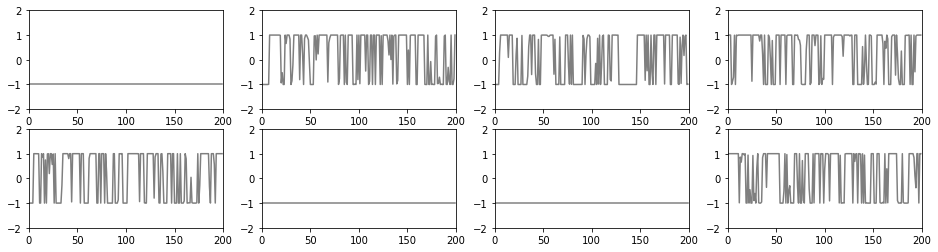

Epoch [4201/5000] -----------------------------------------------------------------------------
G: 15.225442171096802, Dr : 2.919406074397557e-05, Df : 2.654392073964118e-05


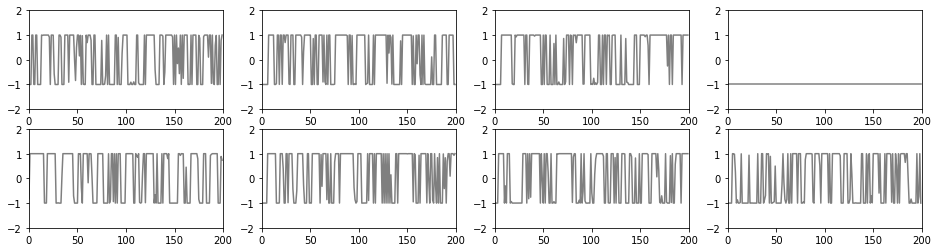

Epoch [4401/5000] -----------------------------------------------------------------------------
G: 15.665310144424438, Dr : 1.420505873284128e-05, Df : 1.139728249199834e-05


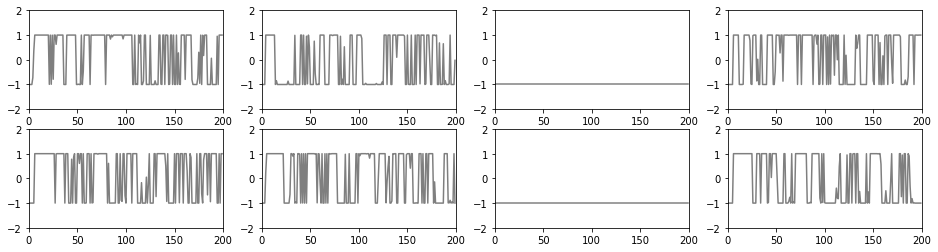

Epoch [4601/5000] -----------------------------------------------------------------------------
G: 16.30589461326599, Dr : 1.07185187516734e-05, Df : 1.0697471225284971e-05


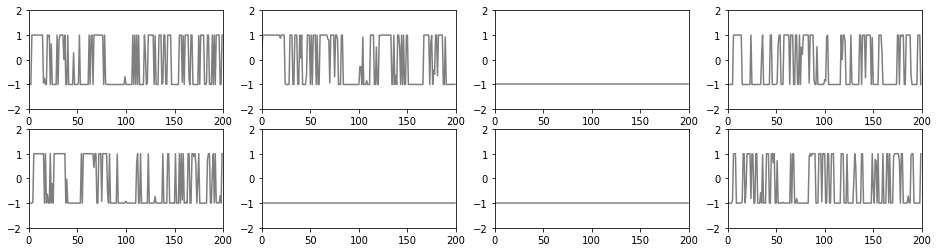

Epoch [4801/5000] -----------------------------------------------------------------------------
G: 17.005579948425293, Dr : 7.07333651916997e-06, Df : 6.492193165286153e-06


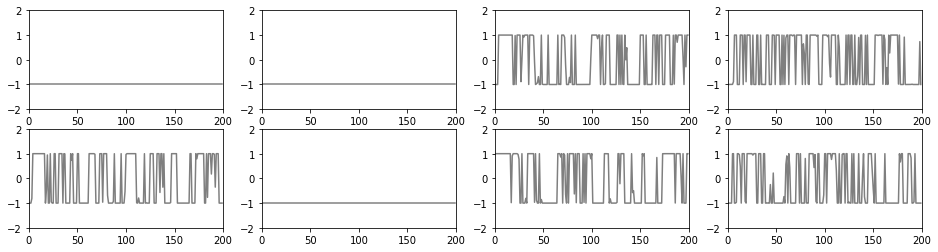

In [ ]:
# Train the model
nb_epoch = 5000

for epoch in range(nb_epoch):
    i = 0

    # if epoch%50 == 0:
    #     lr /= 10
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, x in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)

        discriminator.zero_grad()
        pred_real = discriminator(x)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((batch_size, 200, 5), device=device)
        with torch.no_grad():
            fake_samples = generator(z)
        pred_fake = discriminator(fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()
        
        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((batch_size, 200, 5), device=device) 

        generated = generator(z)
        classifications = discriminator(generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()
    
    if epoch%200 == 0:
      print('Epoch [{}/{}] -----------------------------------------------------------------------------'
          .format(epoch+1, nb_epoch, i, len(train_loader)))
      print('G: {}, Dr : {}, Df : {}'
          .format(loss_g_running/batch, loss_d_real_running/batch, loss_d_fake_running/batch))
      
      traj_sim = generated.detach().numpy()
      plt.figure(figsize = (16,4))
      for i in range(8):
        plt.subplot(2,4,i+1)
        plt.plot(traj_sim[i,0,:], c = 'black', alpha = 0.5)
        plt.xlim(0,length)
        plt.ylim(-2,2)

      plt.show()
      plt.close()



In [ ]:
# torch.save(generator, 'basicGAN_cnn_G.pt')
# torch.save(discriminator, 'basicGAN_cnn_D.pt')

# # generator = torch.load('basicGAN_cnn_G.pt')
# # discriminator = torch.load('basicGAN_cnn_D.pt')